# Ejercicion de programación - Regresión Logistica

LAB2

Estudiante: Chelsea M. Espinoza Cava

Carrera: Ing. de Sistemas

In [96]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [97]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Librerias para graficar
from matplotlib import pyplot

import pandas as pd
#Busca valores similares en el data
from sklearn.impute import KNNImputer

from sklearn.model_selection import train_test_split
# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

## Regresion Logistica

En este laboratorio se implementa un modelo de regresión logística para predecir la presencia de diabetes mellitus en pacientes utilizando variables clínicas. Se utiliza el dataset TrainingWiDS2021, del cual se seleccionaron 30000 registros y seis variables relevantes. El modelo aprende a clasificar si un paciente tiene o no diabetes a partir de estas características.

In [98]:
# Cargar datos
data = pd.read_csv('/content/drive/MyDrive/IA26/DATA/TrainingWiDS2021.csv', delimiter=',')
data_p = data.sample(30000)
X = data_p[['age','bmi','height','weight','temp_apache','heart_rate_apache']]
y = data_p['diabetes_mellitus']
print(X)
print(y)

         age        bmi  height  weight  temp_apache  heart_rate_apache
74603   76.0  32.127688  163.80   86.20        35.70               44.0
30987   38.0        NaN  160.00     NaN        36.50               38.0
64262   48.0  27.071605  167.00   75.50        36.11              114.0
21145   62.0  17.396738  157.40   43.10        36.40               62.0
13538   84.0  29.756932  170.20   86.20        36.50               49.0
...      ...        ...     ...     ...          ...                ...
53727   34.0  25.682980  185.00   87.90        35.90               40.0
124574  61.0  25.104125  175.26   77.11        36.39              126.0
98072   78.0  26.329669  157.00   64.90        36.50               65.0
4633    52.0  28.259890  149.90   63.50        36.70               86.0
37697   80.0  26.344120  167.60   74.00        36.20               95.0

[30000 rows x 6 columns]
74603     0
30987     0
64262     0
21145     0
13538     0
         ..
53727     0
124574    1
98072     0
46

In [99]:
# columnas que estás usando
cols = ['age','bmi','height','weight','temp_apache','heart_rate_apache']

df = data_p[cols].copy()

imputer = KNNImputer(n_neighbors=5)

X = imputer.fit_transform(df)

print(X)
print(y)

[[ 76.          32.12768781 163.8         86.2         35.7
   44.        ]
 [ 38.          25.41419602 160.          64.72        36.5
   38.        ]
 [ 48.          27.07160529 167.          75.5         36.11
  114.        ]
 ...
 [ 78.          26.32966855 157.          64.9         36.5
   65.        ]
 [ 52.          28.25988952 149.9         63.5         36.7
   86.        ]
 [ 80.          26.34411971 167.6         74.          36.2
   95.        ]]
74603     0
30987     0
64262     0
21145     0
13538     0
         ..
53727     0
124574    1
98072     0
4633      0
37697     0
Name: diabetes_mellitus, Length: 30000, dtype: int64


In [100]:
#División entrenamiento/prueba 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)


Entrenamiento: (24000, 6)
Prueba: (6000, 6)


In [101]:
#Normalizamos (media, desvi)
mu = X_train.mean()
sigma = X_train.std()

X_train = (X_train - mu) / sigma
X_test = (X_test - mu) / sigma


In [102]:
X_train = np.concatenate([np.ones((X_train.shape[0],1)), X_train], axis=1)
X_test = np.concatenate([np.ones((X_test.shape[0],1)), X_test], axis=1)

In [103]:
print("Total datos:", len(X))
print("Entrenamiento:", len(X_train))
print("Prueba:", len(X_test))

Total datos: 30000
Entrenamiento: 24000
Prueba: 6000


### Visualizar los datos


In [104]:
def plotData(X, y):

    fig = pyplot.figure()
    pos = y == 1
    neg = y == 0

    pyplot.figure()

    pyplot.scatter(X[pos,1], X[pos,5], marker='*', color='black', s=20)
    pyplot.scatter(X[neg,1], X[neg,5], marker='o', color='yellow', edgecolors='black', s=20)


Se llama a la función implementada para mostrar los datos cargados:

<Figure size 640x480 with 0 Axes>

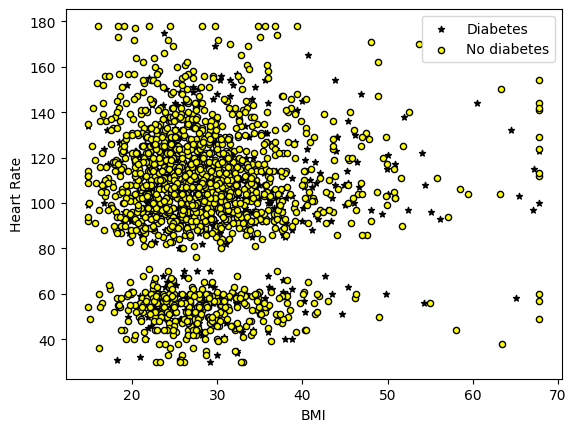

In [105]:
plotData(X[:2000], y[:2000])
# adiciona etiquetas para los ejes
pyplot.xlabel('BMI')
pyplot.ylabel('Heart Rate')
pyplot.legend(['Diabetes','No diabetes'])
pass

Mi modelo usa 6 variables, eso significa que trabaj en 6 dimeciones  osea un hiperplano de 6D no una linea

<a id="section1"></a>
### Implementacion

#### Fución Sigmoidea

La hipotesis para la regresión logistica se define como:

$$ h_\theta(x) = g(\theta^T x)$$

donde la función $g$ is la función sigmoidea. La función sigmoidea se define como:

$$g(z) = \frac{1}{1+e^{-z}}$$.



In [106]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

In [107]:
# Prueba la implementacion de la funcion sigmoid
z = [-100, 0.5, 1000000]
g = sigmoid(z)

print('g(', z, ') = ', g)

g( [-100, 0.5, 1000000] ) =  [3.72007598e-44 6.22459331e-01 1.00000000e+00]


<a id="section2"></a>
#### Función de Costo y Gradiente

Se implementa la funcion cost y gradient, para la regresión logistica. Antes de continuar es importante agregar el termino de intercepcion a X.

La funcion de costo en una regresión logistica es:

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta\left( x^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - h_\theta\left( x^{(i)} \right) \right) \right]$$



In [108]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [109]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

In [110]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.01
num_iters = 5000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X_train.shape[1])
theta, J_history = descensoGradiente(theta, X_train, y_train, alpha, num_iters)


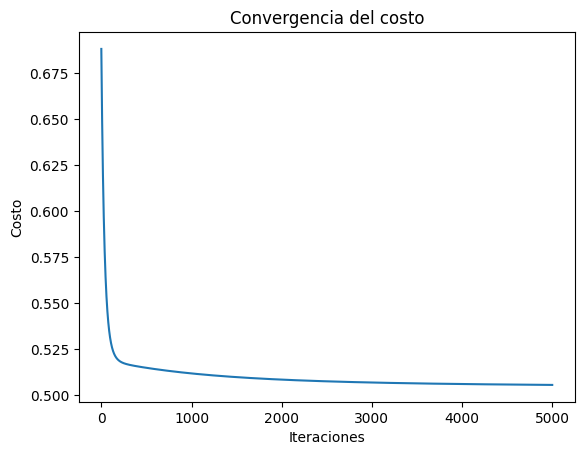

In [111]:
pyplot.plot(np.arange(len(J_history)), J_history)
pyplot.xlabel("Iteraciones")
pyplot.ylabel("Costo")
pyplot.title("Convergencia del costo")
pyplot.show()

In [112]:
def costFunction(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    grad = (1 / m) * (h - y).dot(X)

    return J, grad

<a id="section4"></a>
#### Evaluación de la regresión logistica

Después de aprender los parámetros, se puede usar el modelo para predecir si un paciente en particular tendra diabetes o no.

In [113]:
def predict(theta, X):
    """
    Predecir si la etiqueta es 0 o 1 mediante regresión logística aprendida.
    Calcula las predicciones para X usando un umbral en 0.5 (es decir, si sigmoide (theta.T * x)> = 0.5, predice 1)

    Parametros
    ----------
    theta : array_like
        Parametros para regresion logistica. Un vecto de la forma (n+1, ).

    X : array_like
        Datos utilizados para el calculo de las predicciones.
        La fila es el numero de los puntos para calcular las predicciones,
        y las columnas con el numero de caracteristicas.

    Devuelve
    -------
    p : array_like
        Predicciones y 0 o 1 para cada fila en X.
    """
    m = X.shape[0] # numero de filas

    p = np.zeros(m)

    p = np.round(sigmoid(X.dot(theta.T)))
    return p

Una vez entrenado el modelo se procede a realizar la prediccion y evaluación de los resultados de predecir cual es el valor que vota el modelo para todos los datos utilizados en el entrenamiento.

In [114]:
#evaluacion del modelo
pred_train = predict(theta, X_train)

accuracy_train = np.mean(pred_train == y_train)*100

print("Precisión entrenamiento:", accuracy_train,"%")

pred_test = predict(theta, X_test)

accuracy_test = np.mean(pred_test == y_test)*100

print("Precisión prueba:", accuracy_test,"%")

Precisión entrenamiento: 78.29583333333333 %
Precisión prueba: 78.3 %


In [115]:
# ejemplo de paciente
patient = np.array([[50,30,170,85,37,90]])

# normalizar
patient = (patient - mu)/sigma

# agregar bias
patient = np.concatenate([np.ones((1,1)), patient], axis=1)

prob = sigmoid(patient.dot(theta))

print("Probabilidad de diabetes:", prob[0])

Probabilidad de diabetes: 0.1985419460569883


In [118]:
age = float(input("Edad: "))
peso = float(input("Peso (kg): "))
altura = float(input("Altura (m): "))
temp = float(input("Temperatura corporal: "))
heart = float(input("Frecuencia cardiaca: "))

bmi = peso/(altura**2)

height_cm = altura*100

patient = np.array([[age, bmi, height_cm, peso, temp, heart]])

# normalizar
patient = (patient - mu)/sigma

# agregar bias
patient = np.concatenate([np.ones((1,1)), patient], axis=1)

prob = sigmoid(patient.dot(theta))

print("Probabilidad de diabetes:", round(prob[0],3))

if prob >= 0.5:
    print("Resultado: 1 → Tiene diabetes")
else:
    print("Resultado: 0 → No tiene diabetes")

Edad: 80
Peso (kg): 180
Altura (m): 1.50
Temperatura corporal: 37
Frecuencia cardiaca: 120
Probabilidad de diabetes: 0.614
Resultado: 1 → Tiene diabetes


En este laboratorio se implementó un modelo de regresión logística binaria para predecir la presencia de diabetes mellitus utilizando variables clínicas como edad, índice de masa corporal (BMI), altura, peso, temperatura corporal y frecuencia cardiaca. Estas variables influyen en el modelo ya que permiten describir características físicas y fisiológicas del paciente que pueden estar asociadas con el riesgo de desarrollar diabetes.

El modelo fue entrenado utilizando el 80% de los datos y evaluado con el 20% restante, aplicando descenso por gradiente para encontrar los parámetros óptimos. Los resultados obtenidos muestran que el modelo es capaz de clasificar correctamente los casos de diabetes, demostrando la utilidad de la regresión logística para problemas de clasificación en el análisis de datos médicos.